In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/home/dongmin/userdata/open-score-string-quartets


/home/dongmin/.local/share/virtualenvs/open-score-string-quartets-wd2Cnojv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from pathlib import Path

import math
import random

import json
import csv
import strictyaml as syaml

from tqdm import tqdm
import matplotlib.pyplot as plt

import cv2
import numpy as np

from scripts.utils import PathLike
from scripts.utils import get_ts, dformat, dprint
from scripts.const import excluded_pages

from scripts.mscx_utils import ( 
  convert_mscx_to_musicxml,
  convert_mscx_to_pdf,
  convert_pdf_to_images,
)

/home/dongmin/.local/share/virtualenvs/open-score-string-quartets-wd2Cnojv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
root_dir = Path.cwd()
data_dir = root_dir / 'data'
score_dir = root_dir / 'scores'

In [4]:
data_dir, score_dir

(PosixPath('/home/dongmin/userdata/open-score-string-quartets/data'),
 PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores'))

## Load metadata

In [5]:
with open(data_dir / 'scores_w_infos.yaml') as f:
  metadata = syaml.load(f.read())

metadata = metadata.data

## LMX Rendering

### Load Examples

In [7]:
olimpic_synth_dir = Path.home() / 'userdata' / 'olimpic_dataset_yolo' / 'olimpic-1.0-synthetic'
olimpic_scan_dir = Path.home() / 'userdata' / 'olimpic_dataset_yolo' / 'olimpic-1.0-scanned'

olimpic_synth_dir.exists(), olimpic_scan_dir.exists()

(True, True)

In [8]:
example_synth = (
  olimpic_synth_dir / 'samples' / '6022316' / 'p1-s3.lmx',
  olimpic_synth_dir / 'samples' / '6022316' / 'p1-s3_yolo_resized.png',
)
example_scan = (
  olimpic_scan_dir / 'samples' / '6910703' / 'p2-s2.lmx',
  olimpic_scan_dir / 'samples' / '6910703' / 'p2-s2_yolo_resized.png',
)

sample_synth_lmx, sample_synth_img = example_synth
sample_scan_lmx, sample_scan_img = example_scan
sample_synth_lmx.exists(), sample_synth_img.exists(), sample_scan_lmx.exists(), sample_scan_img.exists()

(True, True, True, True)

### Load YOLO-System model

In [16]:
from ultralytics import YOLO
yolo_system_checkpoint_path = root_dir / 'modules' / 'lsyolo' / 'checkpoints' / 'ls-yolo-system-v2.0.1.pt'
yolo_system = YOLO('yolov8m.pt')
yolo_system._load(weights=str(yolo_system_checkpoint_path))

### Original Image vs. LMX Rendered

100%|██████████| 2/2 [00:09<00:00,  4.55s/it]

0: 640x480 1 system, 16.4ms
1: 640x480 1 system, 16.4ms
Speed: 10.0ms preprocess, 16.4ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
[     218.97      324.86      2315.6       608.8]
[     224.79      337.91      2317.7       623.9]


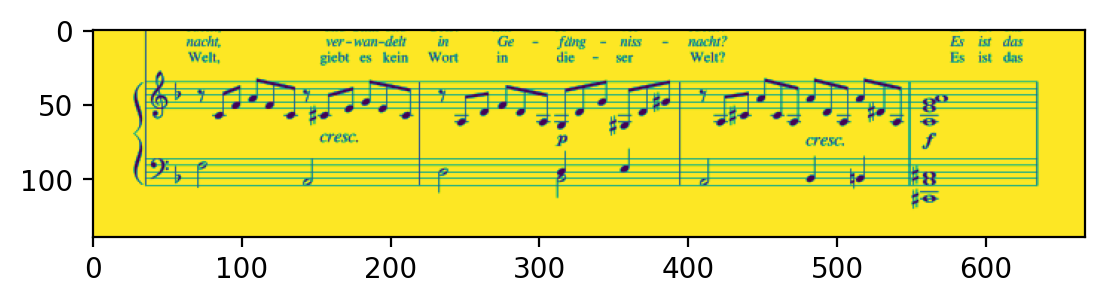

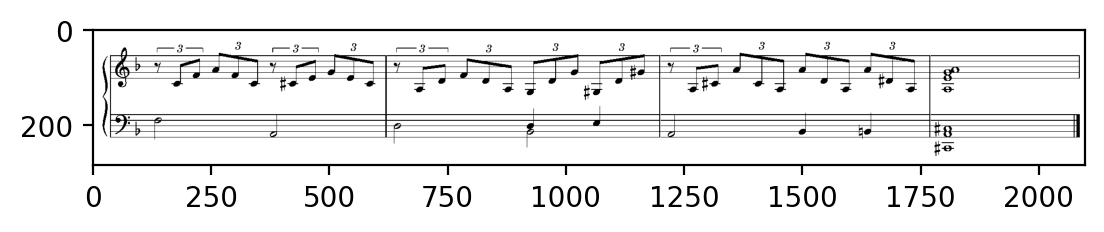

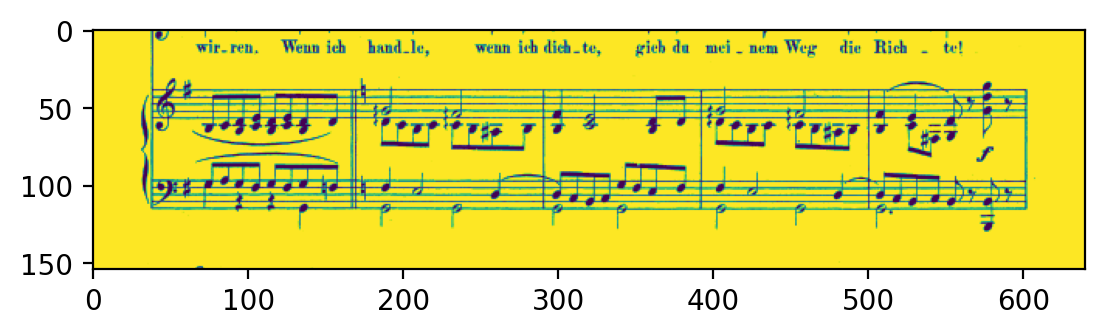

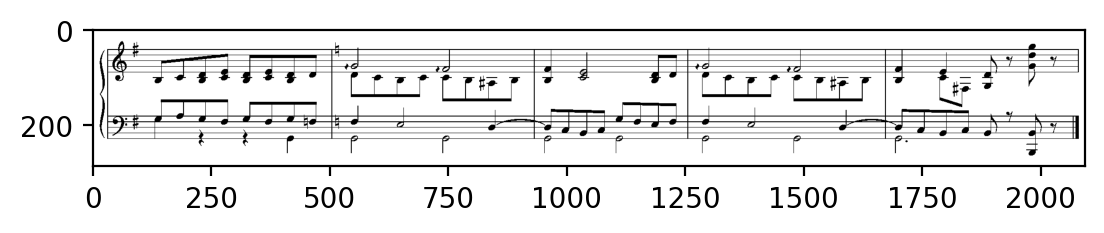

In [27]:
from matplotlib.gridspec import GridSpec
from scripts.mscx_utils import render_lmx
from scripts.utils import merge_yolo_bboxs
from modules.svdp.svdp import bbox_utils

lmx_paths = [ example_synth[0], example_scan[0] ]
total_rendered_paths = render_lmx(lmx_paths, Path.cwd()/'temp')
rendered_paths = [ ls[0] for ls in total_rendered_paths ]
rendered_images = [ cv2.imread(str(p), cv2.IMREAD_UNCHANGED) for p in rendered_paths ]

yolo_results = yolo_system(rendered_images)

for i, (res, img) in enumerate(zip(yolo_results, rendered_images)):
  bboxs = res.boxes.xyxy.cpu().numpy()
  bboxs = merge_yolo_bboxs(bboxs)
  
  bbox = bboxs[0] if len(bboxs) > 0 else None
  
  if bbox is not None:
    img = img[
      int(bbox[1]):int(bbox[3]),
      int(bbox[0]):int(bbox[2])
    ]
  
  rendered_images[i] = img


for img_p, rendered in zip([example_synth[1], example_scan[1]], rendered_images):
  img = cv2.imread(str(img_p), cv2.IMREAD_GRAYSCALE)
  
  plt.imshow(img)
  plt.show()
  plt.imshow(rendered)
  plt.show()

## LMXE Rendering

### Load Examples

In [8]:
lmxe_examples = [
  (
    score_dir / 'Bartók,_Béla/String_Quartet_No.2,_Op.17_(Sz.67)/lmxe/sq8741475:0015:0004.system.lmxe',
    score_dir / 'Bartók,_Béla/String_Quartet_No.2,_Op.17_(Sz.67)/images/synthetic/crop_resized/sq8741475:0015:0004.png',
  ),
  (
    score_dir / 'Debussy,_Claude/String_Quartet_in_G_minor,_Op.10/lmxe/sq8661306:0037:0001.system.lmxe',
    score_dir / 'Debussy,_Claude/String_Quartet_in_G_minor,_Op.10/images/synthetic/crop_resized/sq8661306:0037:0001.png'
  ),
  (
    score_dir / 'Schumann,_Robert/String_Quartet_No.1,_Op.41_No.1/lmxe/sq9010547:0007:0002.system.lmxe',
    score_dir / 'Schumann,_Robert/String_Quartet_No.1,_Op.41_No.1/images/synthetic/crop_resized/sq9010547:0007:0002.png'
  )
]

all([ p.exists() for t in lmxe_examples for p in t])

True

### Load YOLO-System model

In [9]:
from ultralytics import YOLO
yolo_system_checkpoint_path = root_dir / 'modules' / 'lsyolo' / 'checkpoints' / 'ls-yolo-system-v2.0.1.pt'
yolo_system = YOLO('yolov8m.pt')
yolo_system._load(weights=str(yolo_system_checkpoint_path))

### Original Image vs. LMXE Rendered

In [11]:
import sys
from modules.lmxe.lmxe import load_lmxe
from modules.lmxe.lmxe.symbolic.part_to_score import string_quartet_parts_to_score
from modules.lmxe.lmxe.Delinearizer import SQDelinearizer

lmxe = load_lmxe(lmxe_examples[2][0])

delinearizer = SQDelinearizer()
xml_parts = delinearizer.process_text( lmxe )

xml_parts

[<Element 'part' at 0x739993cb3380>,
 <Element 'part' at 0x7399936c2610>,
 <Element 'part' at 0x739993cb0c20>,
 <Element 'part' at 0x7399987630b0>]

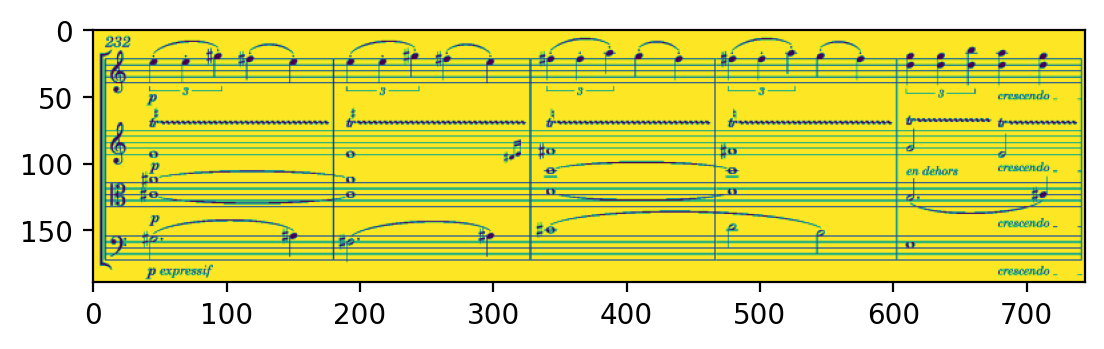

In [12]:
plt.imshow( cv2.imread(str(lmxe_examples[1][1]), cv2.IMREAD_GRAYSCALE) )

100%|██████████| 3/3 [00:13<00:00,  4.56s/it]



0: 640x480 1 system, 25.2ms
1: 640x480 1 system, 25.2ms
2: 640x480 1 system, 25.2ms
Speed: 2.2ms preprocess, 25.2ms inference, 18.3ms postprocess per image at shape (1, 3, 640, 480)


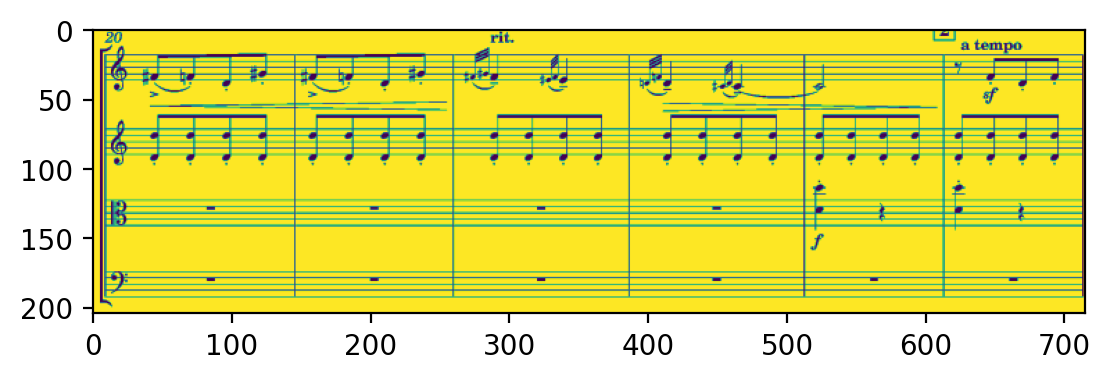

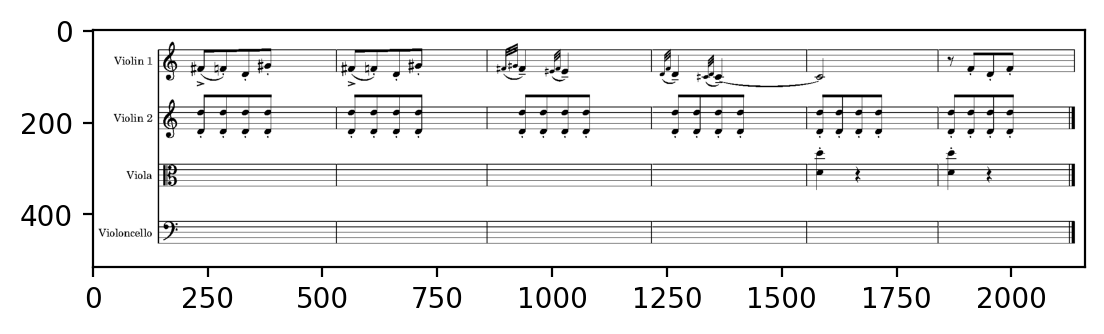

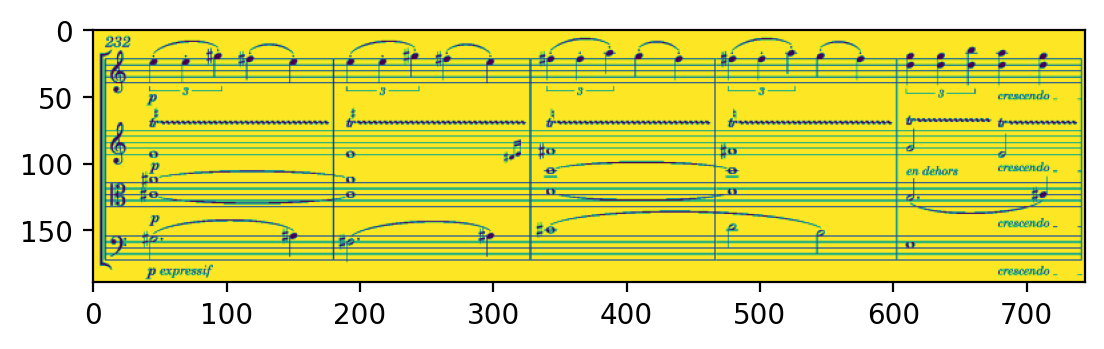

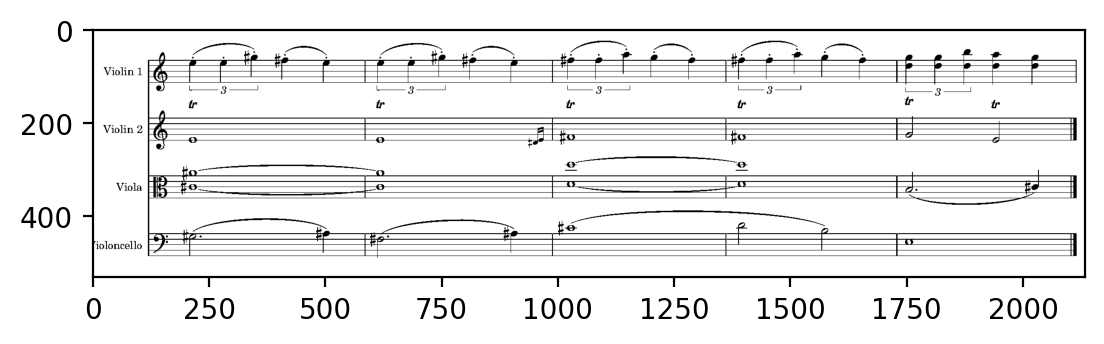

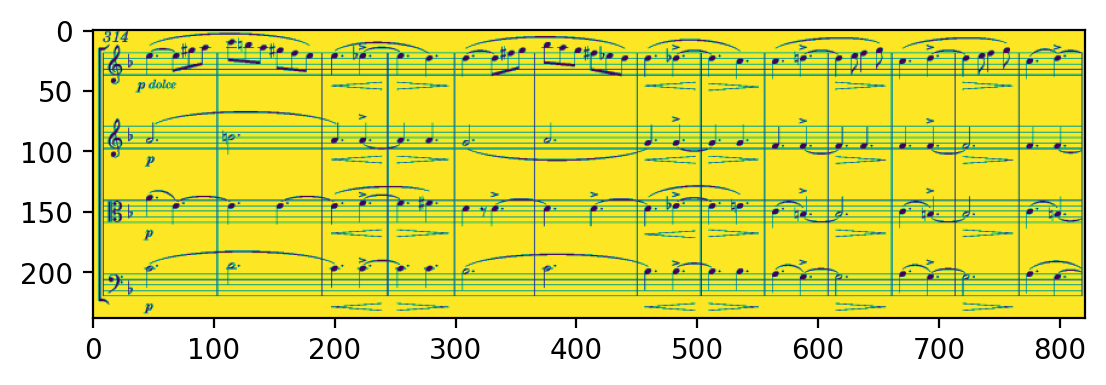

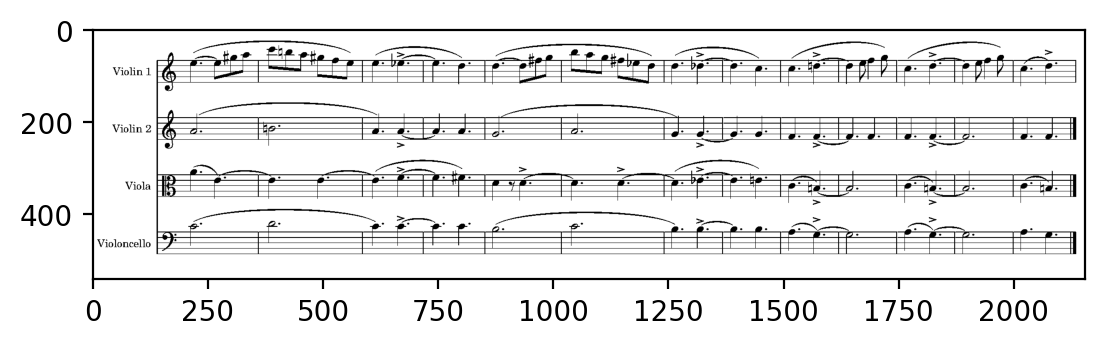

In [13]:
from matplotlib.gridspec import GridSpec
from scripts.mscx_utils import render_lmx
from scripts.utils import merge_yolo_bboxs


lmx_paths = [ ex[0] for ex in lmxe_examples ]
total_rendered_paths = render_lmx(lmx_paths, Path.cwd()/'temp', type='lmxe')
rendered_paths = [ ls[0] for ls in total_rendered_paths ]
rendered_images = [ cv2.imread(str(p), cv2.IMREAD_UNCHANGED) for p in rendered_paths ]

yolo_results = yolo_system(rendered_images)

for i, (res, img) in enumerate(zip(yolo_results, rendered_images)):
  bboxs = res.boxes.xyxy.cpu().numpy()
  bboxs = merge_yolo_bboxs(bboxs)
  
  bbox = bboxs[0] if len(bboxs) > 0 else None
  
  if bbox is not None:
    img = img[
      int(bbox[1]):int(bbox[3]),
      int(bbox[0]):int(bbox[2])
    ]
  
  rendered_images[i] = img


for img_p, rendered in zip([i_p for _, i_p in lmxe_examples], rendered_images):
  img = cv2.imread(str(img_p), cv2.IMREAD_GRAYSCALE)
  
  plt.imshow(img)
  plt.show()
  plt.imshow(rendered)
  plt.show()